# TSARA — combining measurements without inventing any

**Phase 4 walkthrough.** Run top to bottom. Every number and figure below is
produced by the package itself from data manufactured in this notebook. No real
measurement is read anywhere and nothing needs mounting to run it.

---

## Why this phase needs more proof than the last three

Everything before this point applies a **declared, exact, one-to-one map**. A
unit conversion multiplies by a number the manifest states. A per-point sigma
comes from a budget the manifest states. A timestamp moves to the middle of the
cell whose boundaries the file states. Each of those is invertible, and the
product still records what went in.

Nothing in this phase is. A binned value is a weighted mean **no instrument
reported**, formed from many values, and there is no way back to them. That
asymmetry is why `docs/METHODS.md` §11.1 sets out five kinds of evidence for
this phase, and why this notebook spends most of its length on evidence rather
than on description.

The other thing that changes here: ingestion carries its own correctness
signal. A file parses or it does not; a schema validates or it does not. A
transformation carries none. A binned value, a propagated sigma and an
interpolated position all come back looking perfectly reasonable when they are
wrong.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsara.align import bin_streams_onto_cells
from tsara.core.support import CellBounds
from tsara.synthetic import generate
from tsara.synthetic.config import SyntheticConfig

# --- figure style (identical to notebooks 01, 02 and 03) -------------------
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def bounds_of(stream):
    """Cell start and stop of a stream, as datetime64 arrays for plotting."""
    edges = stream["time_bnds"].values
    return edges[:, 0], edges[:, 1]


def cells_of(stream):
    """Return a stream's cells as the CellBounds the binning primitive takes."""
    edges = stream["time_bnds"].values
    return CellBounds(
        start_ns=edges[:, 0].astype("datetime64[ns]").astype("int64"),
        stop_ns=edges[:, 1].astype("datetime64[ns]").astype("int64"),
    )


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so no line is drawn across a gap.

    matplotlib rules a straight segment between consecutive points, so a record
    with a hole in it renders as a smooth ramp across the hole -- an
    interpolation of exactly the kind TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


SECOND = 1_000_000_000

_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)

print("ready")

ready


---
## 1. The one operation

TSARA joins data in exactly one way:

> **every value is averaged onto the target cells, weighted by how much of it
> falls inside each one.**

That is the whole of it. Everything this phase produces is that operation with
a different choice of target. A species pair for a regression targets the
**wider-supported** member's own cells. A campaign matrix for receptor
modelling targets a **uniform grid**. They are not two designs, and writing
them as two implementations was a design inversion caught during the build —
`pair_species` is now `bin_streams_onto_cells` with two variables selected and
incomplete rows dropped.

The function is deliberately **variable-agnostic**. It does not know what a
species is. It takes whatever it is handed — raw concentrations now, baselines
and enhancements once Phase 5 computes them, met, anything a later stage
invents — and puts it on the support asked for.

Before any real-shaped data, here is the arithmetic on a case small enough to
check with a pencil.

In [2]:
import xarray as xr


def demo_cells(start_s, width_s, n):
    """Return ``n`` abutting cells of ``width_s`` seconds."""
    start = (np.arange(n, dtype=np.int64) * int(width_s * SECOND)) + int(start_s * SECOND)
    return CellBounds(start_ns=start, stop_ns=start + int(width_s * SECOND))


def demo_stream(bounds, values):
    """Build a minimal one-variable stream carrying CF cell boundaries."""
    stream = xr.Dataset(
        {"ch4": ("time", values, {"units": "ppb", "cell_methods": "time: mean"})},
        coords={
            "time": bounds.midpoint_ns.astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([bounds.start_ns, bounds.stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
    )
    stream["time"].attrs["bounds"] = "time_bnds"
    return stream


source = demo_cells(0, 1, 5)  # five 1 s cells, values 1..5
five = demo_stream(source, np.array([1.0, 2.0, 3.0, 4.0, 5.0]))
holed = demo_stream(source, np.array([1.0, 2.0, np.nan, 4.0, 5.0]))

# Four targets, four pencil answers.
straddle = CellBounds(start_ns=np.array([int(2.5 * SECOND)]), stop_ns=np.array([int(7.5 * SECOND)]))
cases = [
    ("one 5 s cell over all five", five, demo_cells(0, 5, 1), "(1+2+3+4+5)/5 = 3.0", "1.0"),
    ("a 5 s cell from 2.5 s to 7.5 s", five, straddle, "(0.5*3 + 1*4 + 1*5)/2.5 = 4.2", "0.5"),
    ("the same, with one value masked", holed, demo_cells(0, 5, 1), "(1+2+4+5)/4 = 3.0", "0.8"),
    ("a cell with no data in it", five, demo_cells(100, 5, 1), "nan", "0.0"),
]

print(f"{'target':34} {'pencil':30} {'TSARA':>9} {'n':>3} {'cov':>6}")
for label, stream, target, pencil, cov in cases:
    out = bin_streams_onto_cells({"demo": stream}, target)
    print(
        f"{label:34} {pencil:30} {out['ch4'].values[0]:>9.3f} "
        f"{out['n_source_ch4'].values[0]:>3d} {out['coverage_ch4'].values[0]:>6.2f}"
    )

target                             pencil                             TSARA   n    cov
one 5 s cell over all five         (1+2+3+4+5)/5 = 3.0                3.000   5   1.00
a 5 s cell from 2.5 s to 7.5 s     (0.5*3 + 1*4 + 1*5)/2.5 = 4.2      4.200   3   0.50
the same, with one value masked    (1+2+4+5)/4 = 3.0                  3.000   4   0.80
a cell with no data in it          nan                                  nan   0   0.00


Four things are worth reading off that table rather than taking on trust.

**Partial overlap is weighted, not counted.** The second row's target starts
half way through a source cell, and that cell contributes half as much as its
neighbours. A nearest-timestamp join would have counted it whole or dropped it
entirely; both are wrong by the same half second.

**A masked value lowers coverage instead of vanishing.** The third row still
averages to 3.0, but it says so over four contributing cells covering 0.8 of
the target. A caller who needs four-fifths of a cell measured can see that it
is; nothing is silently filled in.

**An empty cell stays `nan`.** Gases are binned, never interpolated. The
function will not reach for a neighbour.

**`n_source` and `coverage` are not decoration.** They are the two numbers that
separate a well-determined value from a number that merely exists, and the next
figure is about what happens when you ignore them.

---
## 2. The operation on a real-shaped campaign

One source of methane, seen by two instruments that disagree about what a row
means: a 1 Hz analyzer taking point samples, and the shape of the whole
stationary suite — a 60 s **mean**, start-labelled. Their ratio is 1, so they
are the same methane, and any difference between them is the support, the
injected noise, or a defect.

The fast instrument also drops out occasionally, which is what makes coverage
interesting.

In [3]:
SPEC = {
    "name": "align_demo",
    "seed": 7,
    "start": "2026-06-15T14:00:00Z",
    "duration": "1h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "instruments": {
        # A point sampler: one reading per second, cell centred on it.
        "fast": {
            "native_rate": "1s",
            "support": {"method": "point", "label": "mid"},
            "dropouts": {"rate_per_day": 90.0, "duration": "40s"},
            "species": {
                "ch4": {
                    "background": {"kind": "parametric", "offset": 1900.0},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 1.5}},
                }
            },
        },
        # The stationary suite's shape: 60 s means whose timestamp names the
        # START of the minute, which is the ICARTT convention.
        "minute": {
            "native_rate": "60s",
            "support": {"method": "mean", "label": "start"},
            "species": {
                "minute_ch4": {
                    "background": {"kind": "parametric", "offset": 1900.0},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 0.4}},
                }
            },
        },
    },
    "sources": {
        "well_pad": {
            "rate_per_hour": 26.0,
            "reference_species": "ch4",
            # Sharp: about 20 s wide, so a 60 s cell has something to dilute.
            "shape": {"kind": "emg", "sigma": "6s", "tau": "12s"},
            "amplitude": {"kind": "lognormal", "median": 300.0, "sigma_log": 0.3},
            # Ratio 1: the same methane on two clocks, not a second gas.
            "ratios": {"minute_ch4": {"mean": 1.0, "relative_spread": 0.01}},
        }
    },
}

data = generate(SyntheticConfig.model_validate(SPEC))
fast, minute = data.streams["fast"], data.streams["minute"]

# One call does the whole join: both streams, onto the minute instrument's own
# cells. The 60 s stream is already on the target, so it passes through
# untouched; the 1 Hz stream is averaged onto it.
joined = bin_streams_onto_cells(
    {"fast": fast, "minute": minute}, cells_of(minute), ["ch4", "minute_ch4"]
)

print(
    f"fast   {fast.sizes['time']:>5} cells   binned         -> tsara_binned = "
    f"{joined['ch4'].attrs['tsara_binned']}"
)
print(
    f"minute {minute.sizes['time']:>5} cells   passed through -> tsara_binned = "
    f"{joined['minute_ch4'].attrs['tsara_binned']}"
)
print(f"\njoined columns: {sorted(map(str, joined.data_vars))}")

fast    3529 cells   binned         -> tsara_binned = 1
minute    60 cells   passed through -> tsara_binned = 0

joined columns: ['ch4', 'coverage_ch4', 'coverage_minute_ch4', 'minute_ch4', 'n_source_ch4', 'n_source_minute_ch4']


The 60 s instrument was **not** averaged onto itself. The check is on the
cells, not on the instrument name, because averaging a cell onto itself is the
identity mathematically and not in floating point — and several gases retrieved
from one spectrum is the commonest case there is.

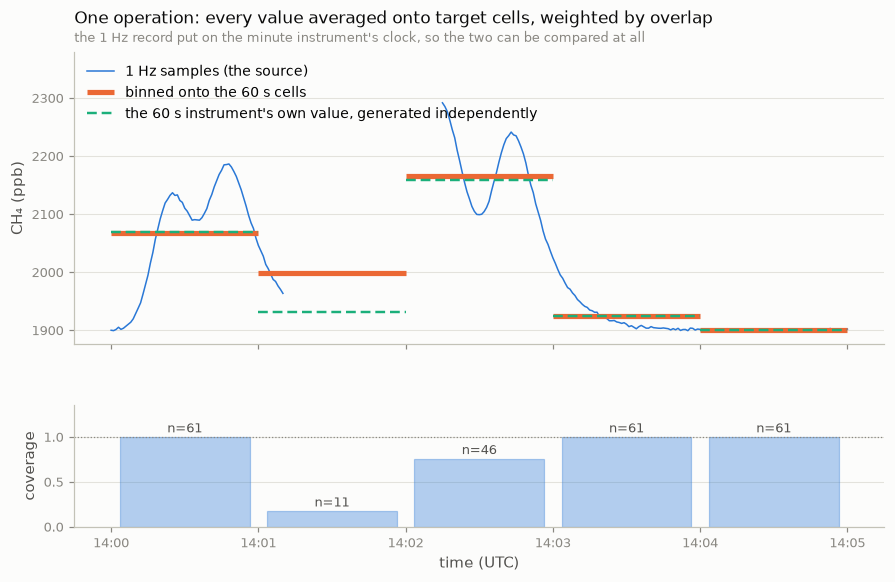

all 60 cells           : median |diff|  0.456 ppb, max  66.669 ppb
the 56 fully covered   : median |diff|  0.431 ppb, max   1.900 ppb

the worst cell has coverage 0.175 and 11 contributing samples


In [4]:
# Pick the window from the data, not by guessing: centre it on the cell with
# the least coverage, which is where the dropout is.
cov = joined["coverage_ch4"].values
centre = pd.Timestamp(joined["time"].values[int(np.argmin(cov))])
w0 = max(centre - pd.Timedelta("2min"), pd.Timestamp(fast["time"].values[0]).floor("min"))
WINDOW = (w0, w0 + pd.Timedelta("5min"))

win = joined.sel(time=slice(*WINDOW))
cell_start, cell_stop = bounds_of(win)
fast_win = fast.sel(time=slice(*WINDOW))
t_fast, v_fast = break_gaps(fast_win["time"].values, fast_win["ch4"].values)

fig, (ax, axc) = plt.subplots(
    2, 1, figsize=(9.5, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.3}
)
ax.plot(t_fast, v_fast, color=C1, lw=1.0, label="1 Hz samples (the source)")
ax.hlines(
    win["ch4"].values, cell_start, cell_stop, color=C2, lw=3.4, label="binned onto the 60 s cells"
)
ax.hlines(
    win["minute_ch4"].values,
    cell_start,
    cell_stop,
    color=C3,
    lw=1.6,
    ls=(0, (4, 2)),
    label="the 60 s instrument's own value, generated independently",
)
low, high = np.nanmin(v_fast), np.nanmax(v_fast)
ax.set_ylim(low - 0.05 * (high - low), high + 0.22 * (high - low))
finish(
    ax,
    "One operation: every value averaged onto target cells, weighted by overlap",
    "the 1 Hz record put on the minute instrument's clock, so the two can be compared at all",
    "CH₄ (ppb)",
    legend=True,
    loc="upper left",
)
mid = cell_start + (cell_stop - cell_start) / 2
axc.bar(
    mid,
    win["coverage_ch4"].values,
    width=(cell_stop - cell_start) * 0.88,
    color=C1,
    alpha=0.35,
    edgecolor=C1,
    lw=0.8,
)
for x, c, n in zip(mid, win["coverage_ch4"].values, win["n_source_ch4"].values):
    axc.text(x, c + 0.05, f"n={n}", ha="center", fontsize=8.2, color=INK2)
axc.axhline(1.0, color=MUTED, lw=0.8, ls=":")
axc.set_ylim(0, 1.35)
finish(axc, None, None, "coverage", "time (UTC)")
hhmm(axc)
plt.show()

diff = np.abs(joined["ch4"].values - joined["minute_ch4"].values)
full = joined["coverage_ch4"].values > 0.99
worst = int(np.argmax(diff))
print(
    f"all {diff.size} cells           : median |diff| {np.median(diff):6.3f} ppb, "
    f"max {diff.max():7.3f} ppb"
)
print(
    f"the {int(full.sum())} fully covered   : median |diff| {np.median(diff[full]):6.3f} ppb, "
    f"max {diff[full].max():7.3f} ppb"
)
print(
    f"\nthe worst cell has coverage {cov[worst]:.3f} and {joined['n_source_ch4'].values[worst]} "
    f"contributing samples"
)

The bars span the minute they are the mean of, rather than sitting as markers
at an instant, for the same reason as in notebook 03: there is no curve to read
through them.

Two things in that figure are the whole argument for carrying `coverage`.

**The orange and the green agree almost everywhere.** They were built by
completely different routes — the green by the generator integrating truth
inside each cell, the orange by TSARA averaging 1 Hz samples over the same
bounds — and across the fully covered cells they differ by less than 2 ppb on
values near 2000. That is an independent construction, not a self-consistency
check.

**Where they disagree badly, coverage says so first.** One cell is out by tens
of ppb, and it is exactly the cell the dropout hit: a fifth of its minute was
measured, and the surviving samples happened to catch a plume's rising edge.
Nothing in the *value* reveals that. `coverage` and `n_source` do, which is why
they travel automatically rather than on request.

Note also that a fully covered 60 s cell has **61** contributing samples, not
60. The 1 s cells are centred on their timestamps, so a minute contains 59
whole ones and two halves. The weighting handles it; a count would not.

---
## 3. How close is "almost everywhere"?

The number above mixes three things: the binner's arithmetic, the noise
deliberately injected into both instruments, and a deliberate 1 % spread
between the two species' plume amplitudes. Only the first is TSARA's.

So take them away one at a time. If the binner is exact, the disagreement
should fall to the injected noise and then to nothing.

In [5]:
import copy

MOVING_BACKGROUND = {
    "kind": "parametric",
    "offset": 1900.0,
    "diurnal_amplitude": 40.0,
    "drift_per_day": 60.0,
}


def gaps(seed, *, plumes, noise, spread=0.0):
    """Rebuild the campaign with one thing changed, and return the per-cell gap."""
    spec = copy.deepcopy(SPEC)
    spec["seed"] = seed
    # Push the generator's own quadrature well below anything measured here: it
    # renders a `mean` cell by averaging truth at `subsamples` points inside it,
    # and the first row of the table below is a claim at 1e-4 ppb.
    spec["instruments"]["minute"]["support"]["subsamples"] = 256
    # The dropouts belong to the figure above, not to this table: a row here
    # is meant to isolate one term, and a partly covered cell is a third one.
    spec["instruments"]["fast"].pop("dropouts", None)
    for instrument in spec["instruments"].values():
        for species in instrument["species"].values():
            # A flat background would make the no-plume rows vacuous: a constant
            # averages to itself however wrong the weights are.
            species["background"] = dict(MOVING_BACKGROUND)
            if not noise:
                species.pop("uncertainty", None)
    if plumes:
        spec["sources"]["well_pad"]["ratios"]["minute_ch4"]["relative_spread"] = spread
    else:
        spec["sources"] = {}
    built = generate(SyntheticConfig.model_validate(spec))
    got = bin_streams_onto_cells(
        dict(built.streams), cells_of(built.streams["minute"]), ["ch4", "minute_ch4"]
    )
    gap = got["ch4"].values - got["minute_ch4"].values
    return gap[got["coverage_ch4"].values > 0.99]


# One hour is 60 cells, and the spread of a statistic over 60 values is wide
# enough to argue with. Twelve seeds is 720, where the rms is good to a few
# percent -- small enough that the comparison below means something.
SEEDS = range(1, 13)

# If the binner is exact, the only thing left between the two instruments is
# the noise each had injected: 1.5 ppb averaged over 61 samples, against 0.4.
predicted = float(np.hypot(1.5 / np.sqrt(61), 0.4))
print(f"predicted sigma of the difference, declared noise only: {predicted:.4f} ppb\n")

print(f"{'campaign':46} {'cells':>6} {'rms gap':>10}  {'vs predicted':>12}")
for label, kwargs in [
    ("a moving background, no plumes, no noise", {"plumes": False, "noise": False}),
    ("plumes too, still no noise", {"plumes": True, "noise": False}),
    ("the declared noise, no plumes", {"plumes": False, "noise": True}),
    ("plumes and noise, identical amplitudes", {"plumes": True, "noise": True}),
    ("as configured: a 1% spread between them", {"plumes": True, "noise": True, "spread": 0.01}),
]:
    pooled = np.concatenate([gaps(seed, **kwargs) for seed in SEEDS])
    rms = float(np.sqrt((pooled**2).mean()))
    print(f"{label:46} {pooled.size:>6} {rms:>10.2e}  {rms / predicted:>11.3f}x")

predicted sigma of the difference, declared noise only: 0.4437 ppb

campaign                                        cells    rms gap  vs predicted
a moving background, no plumes, no noise          720   9.75e-05        0.000x


plumes too, still no noise                        720   1.29e-01        0.291x
the declared noise, no plumes                     720   4.41e-01        0.994x


plumes and noise, identical amplitudes            720   4.58e-01        1.033x


as configured: a 1% spread between them           720   8.80e-01        1.983x


Read that ladder from the top.

**The weighting is right.** With a background that moves but no plumes and no
noise, TSARA's overlap-weighted average of the 1 Hz record and the generator's
own integral of the same truth agree to an rms of about **1 × 10⁻⁴ ppb**, on a
background sweeping several ppb. Two independent constructions, five decimal
places.

**Sharp structure costs about 0.13 ppb, and it is not the binner's.** The fast
instrument takes *point samples* of a plume some 20 s wide; the minute
instrument *integrates* the same plume. One second of sampling grid is the
whole difference between them, and no weighting scheme can close it. It is a
property of the data.

**The binner is transparent to noise, to 0.6 %.** With the declared noise and
nothing else, the measured rms gap over 720 cells is **0.994×** what the two
declared sigmas predict. This is the row that matters: the whole uncertainty
model assumes that averaging does to the error exactly what the algebra says,
and here that assumption is tested against draws rather than against more
algebra.

**And the rows add in quadrature, as they must.** Plumes and noise together
give 1.033×, against √(0.994² + 0.291²) = 1.036 predicted from the two rows
above. Nothing is double-counted and nothing is missing.

The last row is the deliberate 1 % amplitude spread between the two species —
the largest term in the figure further up, and the one piece of that
disagreement that is neither the support nor the noise nor TSARA.

---
## 4. The direction that is refused

The operation is symmetric in the code and **must not be** in use. Averaging a
fast stream onto slow cells discards resolution the slow instrument never had,
which is honest. Doing it the other way round — evaluating a 60 s mean on 1 s
cells — invents no *value*, since every row holds a number the instrument
really reported, but it invents **rows**.

Nothing in the output would give it away. A replicated row reports
`coverage = 1.00`, because the target cell really is fully covered by source
data, and `n_source = 1`, which is also what a legitimately sparse canister
measurement reports. The two numbers that exist to flag a badly determined
value both say the value is perfect.

Here is what a naive upsample of the minute instrument would look like, built
by hand, beside what the instrument actually measured.

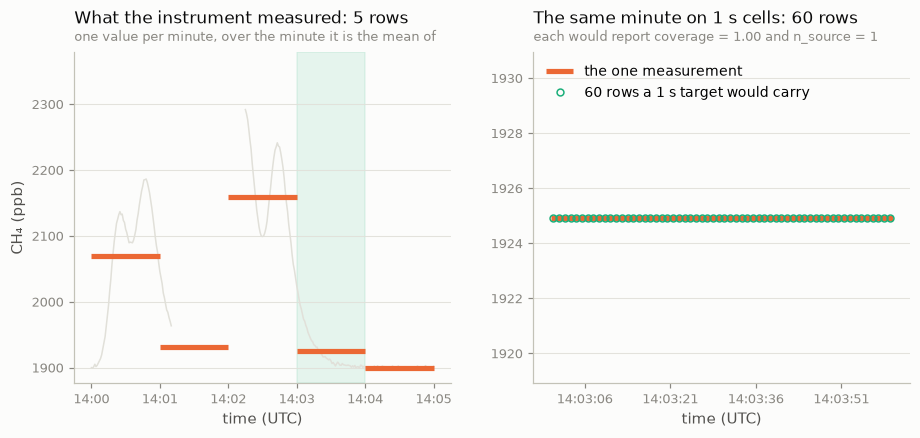

In [6]:
# Built with np.repeat, NOT by TSARA -- the next cell is what TSARA does when
# asked for this. Sixty copies of each minute, one per second.
naive_rows = np.repeat(win["minute_ch4"].values, 60)
naive_clock = pd.date_range(WINDOW[0] + pd.Timedelta("0.5s"), periods=naive_rows.size, freq="1s")

zoom = (WINDOW[0] + pd.Timedelta("3min"), WINDOW[0] + pd.Timedelta("4min"))
in_zoom = (naive_clock >= zoom[0]) & (naive_clock < zoom[1])
zoom_win = win.sel(time=slice(*zoom))
zoom_start, zoom_stop = bounds_of(zoom_win)

fig, (axl, axr) = plt.subplots(1, 2, figsize=(9.8, 3.9), gridspec_kw={"wspace": 0.22})
axl.plot(t_fast, v_fast, color=GRID, lw=1.0, zorder=1)
axl.hlines(win["minute_ch4"].values, cell_start, cell_stop, color=C2, lw=3.4, zorder=3)
axl.set_ylim(low - 0.05 * (high - low), high + 0.22 * (high - low))
axl.axvspan(zoom[0], zoom[1], color=C3, alpha=0.10, zorder=0)
finish(
    axl,
    f"What the instrument measured: {win.sizes['time']} rows",
    "one value per minute, over the minute it is the mean of",
    "CH₄ (ppb)",
    "time (UTC)",
)
hhmm(axl)
axr.hlines(
    zoom_win["minute_ch4"].values,
    zoom_start,
    zoom_stop,
    color=C2,
    lw=3.4,
    zorder=2,
    label="the one measurement",
)
axr.plot(
    naive_clock[in_zoom],
    naive_rows[in_zoom],
    "o",
    color=C3,
    ms=4.5,
    mfc="none",
    mew=1.0,
    zorder=3,
    label=f"{int(in_zoom.sum())} rows a 1 s target would carry",
)
axr.set_ylim(zoom_win["minute_ch4"].values[0] - 6, zoom_win["minute_ch4"].values[0] + 6)
finish(
    axr,
    f"The same minute on 1 s cells: {int(in_zoom.sum())} rows",
    "each would report coverage = 1.00 and n_source = 1",
    None,
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(axr, "%H:%M:%S")
axr.xaxis.set_major_locator(mdates.SecondLocator(interval=15))
plt.show()

In [7]:
from tsara.align import TsaraAlignError

edges = np.arange(int(pd.Timestamp(WINDOW[0]).value), int(pd.Timestamp(WINDOW[1]).value), SECOND)
one_second = CellBounds(start_ns=edges, stop_ns=edges + SECOND)

try:
    bin_streams_onto_cells({"minute": minute}, one_second)
except TsaraAlignError as refused:
    print(refused)

Stream 'minute' has 60 s cells and the target cells are 1 s, so one of its measurements would fill 60 target cells on its own. Evaluating it on a shorter support is resolution the instrument never had (METHODS §11.2), and the replicated rows would enter a fit as independent measurements. Bin onto cells at least as wide, pair on the wider-supported stream, or — for a smooth non-gas field — interpolate it with tsara.align.auxiliary (§11.6).


The refusal counts, on the actual overlaps, how many target cells fall
*entirely* inside one source cell. That is a deliberate choice over comparing
the two median widths, which would need a tolerance: real analyzers disagree
about their own nominal rate, and two in the 2026 archive measure 0.993 s and
1.024 s against a nominal 1 s. Binning one onto the other replicates nothing,
and a strict width rule would refuse it over a 3 % difference. Counting whole
contained cells never reaches two on jitter, however the medians compare.

A grid half a period out of phase with an equal-width source is not refused
either: every source cell then straddles two targets and wholly contains
neither. That case is lossy for a different reason and is warned about
separately.

The escape route for the case that is genuinely wanted — a smooth field on a
finer clock, a wind direction against 1 Hz methane — is the one that already
exists. `tsara.align.auxiliary` interpolates it under a gap guard, and refuses
any variable declaring `role: gas`. That is stage 5 of this walkthrough.

---
## 5. The uncertainty that travels with the value

A binned value is not the only thing this stage produces. Every uncertainty
component is propagated through the **same overlap weights that formed the
value**, and that is deliberate: §3.2 notes that inverse-variance weights are
the minimum-variance choice, which makes it look as though a propagation
routine should use them. It must not. The number being reported was formed
with overlap weights, so an uncertainty computed with any other weights would
not describe it.

TSARA carries two components for every variable, and they behave in opposite
ways under averaging. The demonstration below runs the **whole chain**: a
budget declared in a manifest, written to a CSV file, read back by ingestion,
and propagated by the binner. Nothing is hand-fed.

In [8]:
from tsara.config.loader import load_manifest
from tsara.core.naming import sigma_rand_name, sigma_sys_name
from tsara.ingest import ingest_campaign
from tsara.synthetic.export import export_raw

BUDGET = {
    "name": "budget_demo",
    "seed": 5,
    "start": "2026-01-01T00:00:00Z",
    "duration": "40min",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.85},
    "instruments": {
        "analyzer": {
            "native_rate": "1s",
            "species": {
                "ch4": {
                    "background": {"kind": "parametric", "offset": 1900.0},
                    "role": "gas",
                    "units": "ppb",
                    # Two components, declared separately, because they do
                    # different things when values are combined.
                    "uncertainty": {
                        "random": {"absolute": 2.0},
                        "systematic": {"relative": 0.01},
                    },
                }
            },
        }
    },
    "sources": {},
}

budget_data = generate(SyntheticConfig.model_validate(BUDGET))
ingested = ingest_campaign(load_manifest(export_raw(budget_data, WORK / "budget")))
analyzer = ingested["analyzer"]
print("what came back out of the file:", sorted(map(str, analyzer.data_vars)))
print("provenance:", {k: v for k, v in analyzer["ch4"].attrs.items() if "uncertainty" in k})

SPAN = 2400
epoch = analyzer["time_bnds"].values[0, 0].astype("datetime64[ns]").astype("int64")


def uniform(width_s):
    """Cells of a given width tiling the campaign."""
    k = np.arange(SPAN // width_s, dtype=np.int64)
    return CellBounds(
        start_ns=epoch + k * width_s * SECOND, stop_ns=epoch + (k + 1) * width_s * SECOND
    )


print(
    f"\n{'cell width':>12} {'samples':>9} {'random':>10} {'sigma/sqrt(N)':>14} {'systematic':>12}"
)
per_sample = None
for width_s in (1, 10, 60, 600, 2400):
    cell = bin_streams_onto_cells({"analyzer": analyzer}, uniform(width_s), ["ch4"])
    n = float(np.nanmedian(cell["n_source_ch4"].values))
    rand = float(np.nanmedian(cell[sigma_rand_name("ch4")].values))
    syst = float(np.nanmedian(cell[sigma_sys_name("ch4")].values))
    per_sample = rand if per_sample is None else per_sample
    print(
        f"{width_s:>10d} s {n:>9.0f} {rand:>10.5f} {per_sample / np.sqrt(n):>14.5f} {syst:>12.5f}"
    )

what came back out of the file: ['ch4', 'sigma_rand_ch4', 'sigma_sys_ch4']
provenance: {'uncertainty_source': 'declared', 'uncertainty_source_random': 'declared', 'uncertainty_source_systematic': 'declared'}

  cell width   samples     random  sigma/sqrt(N)   systematic
         1 s         1    2.00000        2.00000     19.05501
        10 s        10    0.63246        0.63246     19.05499
        60 s        60    0.25820        0.25820     19.05483
       600 s       600    0.08165        0.08165     19.05432
      2400 s      2400    0.04082        0.04082     19.05456


The random component follows σ/√N to five decimal places across four orders of
magnitude. The systematic component does not move at all: averaging 2400
samples of a species whose calibration is 1 % uncertain leaves the mean 1 %
uncertain, not 0.02 %. That is not conservatism. It is the exact value of the
§3.1 double sum when every pair is perfectly correlated, which is precisely
what declaring a component systematic asserts.

Collapsing the two into one number before averaging would apply one rule to
both, so they stay separate through the entire pipeline — and the module
offers two functions rather than one with a flag.

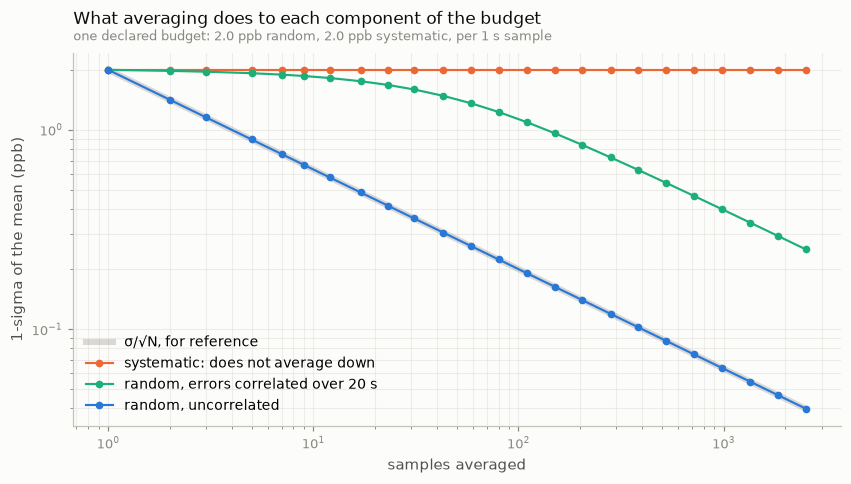

In [9]:
from tsara.core.propagation import propagate_random, propagate_systematic

SIGMA, TAU = 2.0, 20.0
counts = np.unique(np.round(np.logspace(0, 3.4, 26)).astype(int))
independent, correlated, systematic = [], [], []
for n in counts:
    clock = np.arange(n, dtype=float)
    independent.append(propagate_random(np.full(n, SIGMA), np.ones(n)).sigma)
    correlated.append(
        propagate_random(np.full(n, SIGMA), np.ones(n), tau_s=TAU, times_s=clock).sigma
    )
    systematic.append(propagate_systematic(np.full(n, SIGMA), np.ones(n)).sigma)

fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.loglog(
    counts,
    SIGMA / np.sqrt(counts),
    "-",
    color=MUTED,
    lw=4.0,
    alpha=0.30,
    label="σ/√N, for reference",
)
ax.loglog(counts, systematic, "o-", color=C2, ms=4, label="systematic: does not average down")
ax.loglog(
    counts, correlated, "o-", color=C3, ms=4, label=f"random, errors correlated over {TAU:.0f} s"
)
ax.loglog(counts, independent, "o-", color=C1, ms=4, label="random, uncorrelated")
finish(
    ax,
    "What averaging does to each component of the budget",
    f"one declared budget: {SIGMA} ppb random, {SIGMA} ppb systematic, per 1 s sample",
    "1-sigma of the mean (ppb)",
    "samples averaged",
    legend=True,
    loc="lower left",
)
ax.grid(True, which="both", axis="both", alpha=0.55)
plt.show()

The green line is the third case, and the one worth understanding before the
next section: a random component whose errors stay correlated for 20 s. It
starts on σ/√N and peels away, because averaging samples that already agree
with each other buys less than averaging independent ones.

---
## 6. Checked against draws, not against more algebra

Every test so far in this notebook compares one piece of arithmetic with
another. That can prove a formula was *typed* correctly; it can never prove it
was the *right* formula. For an uncertainty the experiment is direct: draw
many realizations of an error whose structure is known, average each one, and
measure how much the averages actually scatter.

The draws below are written from the textbook definition rather than taken
from TSARA's own generator, on purpose — a shared misunderstanding would
otherwise agree with itself.

In [10]:
rng = np.random.default_rng(4)
N, TRIALS = 60, 40_000

# White noise: independent draws, N per realization.
white = rng.normal(0.0, SIGMA, size=(TRIALS, N))

# Systematic: ONE offset per realization, shared by every sample in it. That
# is what "correlated" means, written as a draw.
shared = rng.normal(0.0, SIGMA, size=(TRIALS, 1)) * np.ones((1, N))

# AR(1): each error is rho times the last, plus fresh innovation.
rho = np.exp(-1.0 / TAU)
ar1 = np.empty((TRIALS, N))
ar1[:, 0] = rng.normal(0.0, SIGMA, TRIALS)
innovation = rng.normal(0.0, SIGMA * np.sqrt(1 - rho**2), size=(TRIALS, N - 1))
for k in range(1, N):
    ar1[:, k] = rho * ar1[:, k - 1] + innovation[:, k - 1]

clock = np.arange(N, dtype=float)
ones = np.ones(N)
sigmas = np.full(N, SIGMA)
rows = [
    (
        "white noise",
        white.mean(axis=1).std(ddof=1),
        propagate_random(sigmas, ones).sigma,
        "independent",
    ),
    (
        "systematic",
        shared.mean(axis=1).std(ddof=1),
        propagate_systematic(sigmas, ones).sigma,
        "§3.3",
    ),
    (
        "AR(1), tau = 20 s",
        ar1.mean(axis=1).std(ddof=1),
        propagate_random(sigmas, ones, tau_s=TAU, times_s=clock).sigma,
        "ar1_neff",
    ),
    (
        "the same, other form",
        ar1.mean(axis=1).std(ddof=1),
        propagate_random(sigmas, ones, tau_s=TAU, times_s=clock, form="ar1_asymptotic").sigma,
        "ar1_asymptotic",
    ),
    (
        "the same, reference form",
        ar1.mean(axis=1).std(ddof=1),
        propagate_random(sigmas, ones, tau_s=TAU, times_s=clock, form="ar1_double_sum").sigma,
        "ar1_double_sum",
    ),
    (
        "the same, tau not declared",
        ar1.mean(axis=1).std(ddof=1),
        propagate_random(sigmas, ones).sigma,
        "independent",
    ),
]
print(f"{'case':28} {'observed':>9} {'predicted':>10} {'ratio':>7}  form")
for label, observed, predicted, form in rows:
    print(f"{label:28} {observed:>9.4f} {predicted:>10.4f} {predicted / observed:>7.3f}  {form}")

case                          observed  predicted   ratio  form
white noise                     0.2569     0.2582   1.005  independent
systematic                      1.9921     2.0000   1.004  §3.3
AR(1), tau = 20 s               1.3544     1.3501   0.997  ar1_neff
the same, other form            1.3544     1.6332   1.206  ar1_asymptotic
the same, reference form        1.3544     1.3501   0.997  ar1_double_sum
the same, tau not declared      1.3544     0.2582   0.191  independent


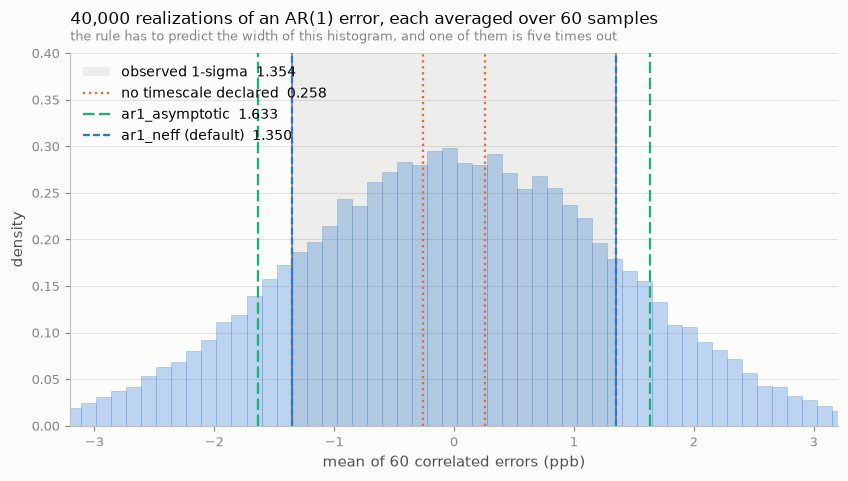

In [11]:
means = ar1.mean(axis=1)
observed = float(means.std(ddof=1))
predictions = {
    "no timescale declared": propagate_random(sigmas, ones).sigma,
    "ar1_asymptotic": propagate_random(
        sigmas, ones, tau_s=TAU, times_s=clock, form="ar1_asymptotic"
    ).sigma,
    "ar1_neff (default)": propagate_random(sigmas, ones, tau_s=TAU, times_s=clock).sigma,
}

fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(means, bins=90, color=C1, alpha=0.30, edgecolor=C1, lw=0.5, density=True)
ax.axvspan(
    -observed, observed, color=INK, alpha=0.06, lw=0, label=f"observed 1-sigma  {observed:.3f}"
)
ax.axvline(observed, color=INK, lw=1.0, alpha=0.55)
ax.axvline(-observed, color=INK, lw=1.0, alpha=0.55)
for (label, value), colour, dashes in zip(
    predictions.items(), (C2, C3, C1), ((0, (1, 1.6)), (0, (5, 2)), (0, (3, 1.4)))
):
    ax.axvline(value, color=colour, lw=1.5, ls=dashes, label=f"{label}  {value:.3f}")
    ax.axvline(-value, color=colour, lw=1.5, ls=dashes)
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(0, 0.40)
finish(
    ax,
    f"{TRIALS:,} realizations of an AR(1) error, each averaged over {N} samples",
    "the rule has to predict the width of this histogram, and one of them is five times out",
    "density",
    f"mean of {N} correlated errors (ppb)",
    legend=True,
    loc="upper left",
)
plt.show()

The dotted orange lines are what you get by treating correlated samples as
independent: a 1-sigma band that sits well inside the bulk of the histogram.
Not imprecise — **confidently wrong**, by a factor of five. That is why
ingestion refuses to rescale a declared sigma when no decorrelation timescale
is available, and records a recorded non-answer instead.

`ar1_neff` lands on the edge of the observed band. `ar1_double_sum`, the
reference form that correlates every pair of samples by the time between them,
returns the same number to the last bit or two of a float64 here — because
these samples are equally spaced with equal sigma, which is exactly the case
the finite-*N* sum evaluates exactly. The next cell is where they part
company.

---
## 7. Where the cheap form costs something, measured

The default form summarises a cell by two numbers: how many samples it holds,
and how far apart they are. That is exact when the samples are evenly spread
through the cell. When a dropout splits a cell into two clumps, the summary no
longer describes the arrangement — and the same thirty samples carry *more*
information when they are spread across a minute than when they sit in two
blocks, because the two blocks have had time to decorrelate from each other.

The module says as much ("the two agree exactly on evenly sampled data"). What
it did not say is how much the difference is worth.

In [12]:
block = ar1[:, :60]
consecutive = block[:, :30]
clumped = np.concatenate([block[:, :15], block[:, 45:]], axis=1)
t_consecutive = np.arange(30, dtype=float)
t_clumped = np.concatenate([np.arange(15, dtype=float), np.arange(45, 60, dtype=float)])

print(f"{'thirty samples, arranged as':28} {'observed':>9} {'ar1_neff':>10} {'exact':>10}")
for label, draws, when in (
    ("one consecutive run", consecutive, t_consecutive),
    ("two blocks, 30 s apart", clumped, t_clumped),
):
    seen = draws.mean(axis=1).std(ddof=1)
    cheap = propagate_random(np.full(30, SIGMA), np.ones(30), tau_s=TAU, times_s=when).sigma
    exact = propagate_random(
        np.full(30, SIGMA), np.ones(30), tau_s=TAU, times_s=when, form="ar1_double_sum"
    ).sigma
    print(
        f"{label:28} {seen:>9.4f} {cheap:>10.4f} {exact:>10.4f}"
        f"   ({cheap / seen:.3f}x, {exact / seen:.3f}x)"
    )

thirty samples, arranged as   observed   ar1_neff      exact
one consecutive run             1.6082     1.6040     1.6040   (0.997x, 0.997x)
two blocks, 30 s apart          1.3439     1.6040     1.3431   (1.194x, 0.999x)


So the cheap form is exact on the even case and overstates the uncertainty by
about a fifth on the split one, while the reference form tracks the draws in
both. The error is in the conservative direction, and it is bounded by how
badly a cell's samples clump — which `n_source` and `coverage` already report.
The reference form is selectable wherever forms are selectable, which is the
point of registering it: a registered name that cannot be chosen is not
registered.

One thing to keep in view for the rest of this phase: **none of the
correlated-error machinery is exercised by the real archive today**, because
no file in it declares a decorrelation timescale and TSARA will not invent
one. Estimating τ from the data is a live question, written up as a future
avenue in `METHODS.md` §7. What the archive *does* exercise is everything
above it: the independent reduction, the systematic non-reduction, and the
provenance that says which was used.

---
## 8. Pairing: the same operation, with a choice of clock

A regression needs two species on one clock. `pair_species` is **not** a
second implementation of joining; it is `bin_streams_onto_cells` with three
decisions made for you:

1. **which cells** — those of the **wider-supported** of the two instruments;
2. **which stretch** — optionally one event or window;
3. **which rows survive** — a pair needs a real measurement of *both* species,
   so a cell missing either is dropped rather than filled.

The first rule used to read "the slower instrument", and rate and support
disagree in exactly the case that matters most. A whole-air canister fills for
about fifteen seconds once every several minutes. Against a 60 s mean it is
roughly nine times slower by rate and four times **narrower** by support.
Pairing on its clock would state a 60 s mean over 15 s of air, which is the
direction section 4 refuses; pairing on the mean's clock is admissible, and
coverage says how much of the minute the canister saw.

The commonest canister pairing is against a fast analyzer, where both rules
agree. Here is one: a 1 Hz methane analyzer, and a canister sampler taking a
15 s fill roughly every nine minutes, with a known benzene-to-methane ratio.

In [13]:
from tsara.align import pair_species

CANISTER = {
    "name": "canister_demo",
    "seed": 21,
    "start": "2026-06-16T15:00:00Z",
    "duration": "8h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "instruments": {
        "analyzer": {
            "native_rate": "1s",
            "species": {
                "ch4": {
                    "background": {"kind": "parametric", "offset": 1950.0},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 2.0}},
                }
            },
        },
        # A duty-cycled sampler: each row is a 15 s mean, and the rows arrive
        # irregularly, about every nine minutes.
        "iwas": {
            "native_rate": "530s",
            "timestamp_jitter": "200s",
            "support": {"method": "mean", "width": "15s"},
            "species": {
                "benzene": {
                    "background": {"kind": "parametric", "offset": 0.05},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 0.01}},
                }
            },
        },
    },
    "sources": {
        "refinery": {
            "rate_per_hour": 14.0,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": "35s"},
            "amplitude": {"kind": "lognormal", "median": 120.0, "sigma_log": 0.6},
            "ratios": {"benzene": {"mean": 0.004}},
        }
    },
}

canister = generate(SyntheticConfig.model_validate(CANISTER))
paired = pair_species(canister.streams, "benzene", "ch4")

print(f"clock : {paired.clock}  ({paired.dataset.attrs['tsara_pairing_clock_reason']})")
print(f"pairs : {paired.n_pairs} from {canister.streams['iwas'].sizes['time']} fills\n")
print(
    paired.dataset[["benzene", "ch4", "n_source_ch4", "coverage_ch4"]]
    .to_dataframe()
    .head(4)
    .round(3)
    .to_string()
)

clock : iwas  (wider cells (15 s vs 1 s))
pairs : 55 from 55 fills

                               benzene       ch4  n_source_ch4  coverage_ch4
time                                                                        
2026-06-16 15:00:11.897017252    0.629  2098.099            16           1.0
2026-06-16 15:08:10.467695855    0.337  2019.403            16           1.0
2026-06-16 15:19:38.410879640    0.062  1951.581            16           1.0
2026-06-16 15:25:54.921599091    0.054  1950.900            16           1.0


The clock is the canister, and the reason says why in terms of cell widths
rather than rates. Each pair's methane is the average of roughly fifteen 1 Hz
samples — sixteen, counting the two partial edge samples as the weighting
does — over exactly the interval the canister filled, with `coverage` 1.0
because the analyzer was running throughout.

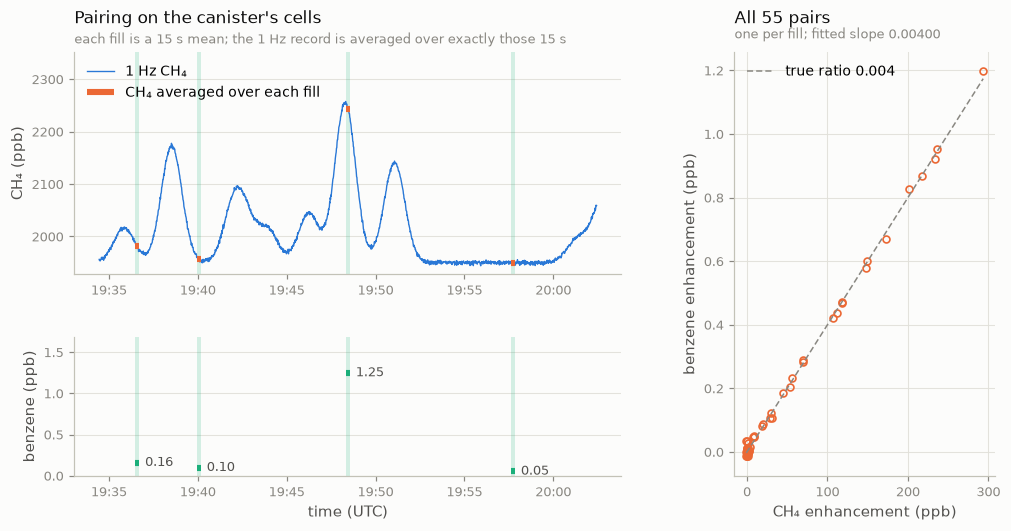

In [14]:
ds = paired.dataset
k = int(np.nanargmax(ds["benzene"].values))
centre = pd.Timestamp(ds["time"].values[k])
SPAN8 = (centre - pd.Timedelta("14min"), centre + pd.Timedelta("14min"))
trace = canister.streams["analyzer"].sel(time=slice(*SPAN8))
t8, v8 = break_gaps(trace["time"].values, trace["ch4"].values)
near = ds.sel(time=slice(*SPAN8))
f0, f1 = bounds_of(near)

fig = plt.figure(figsize=(10.8, 5.0))
gs = fig.add_gridspec(
    2, 2, width_ratios=[2.1, 1.0], height_ratios=[1.6, 1.0], hspace=0.35, wspace=0.28
)
ax = fig.add_subplot(gs[0, 0])
axb = fig.add_subplot(gs[1, 0], sharex=ax)
axs = fig.add_subplot(gs[:, 1])

ax.plot(t8, v8, color=C1, lw=0.9, label="1 Hz CH₄")
for x0, x1 in zip(f0, f1):
    ax.axvspan(x0, x1, color=C3, alpha=0.18, lw=0)
    axb.axvspan(x0, x1, color=C3, alpha=0.18, lw=0)
ax.hlines(near["ch4"].values, f0, f1, color=C2, lw=4.0, label="CH₄ averaged over each fill")
lo8, hi8 = np.nanmin(v8), np.nanmax(v8)
ax.set_ylim(lo8 - 0.05 * (hi8 - lo8), hi8 + 0.3 * (hi8 - lo8))
finish(
    ax,
    "Pairing on the canister's cells",
    "each fill is a 15 s mean; the 1 Hz record is averaged over exactly those 15 s",
    "CH₄ (ppb)",
    legend=True,
    loc="upper left",
)
axb.hlines(near["benzene"].values, f0, f1, color=C3, lw=4.0)
for x0, x1, b in zip(f0, f1, near["benzene"].values):
    axb.text(x0 + (x1 - x0) / 2, b, f"  {b:.2f}", va="center", ha="left", fontsize=8.2, color=INK2)
axb.set_ylim(0, float(np.nanmax(near["benzene"].values)) * 1.35)
finish(axb, None, None, "benzene (ppb)", "time (UTC)")
hhmm(axb)

x_enh = ds["ch4"].values - 1950.0
y_enh = ds["benzene"].values - 0.05
slope8 = np.polyfit(x_enh, y_enh, 1)[0]
axs.plot(x_enh, y_enh, "o", color=C2, ms=4.5, mfc="none", mew=1.1)
line = np.linspace(min(0.0, np.nanmin(x_enh)), np.nanmax(x_enh), 10)
axs.plot(line, 0.004 * line, color=MUTED, lw=1.0, ls=(0, (4, 2)), label="true ratio 0.004")
finish(
    axs,
    f"All {paired.n_pairs} pairs",
    f"one per fill; fitted slope {slope8:.5f}",
    "benzene enhancement (ppb)",
    "CH₄ enhancement (ppb)",
    legend=True,
    loc="upper left",
    grid_axis="both",
)
plt.show()

The green bands are the fills, and the orange bars are what the analyzer saw
over exactly those intervals. Most of the methane record is simply not used:
it has no benzene partner, and pairing does not manufacture one. The fitted
slope comes back at the injected ratio, over one pair per fill.

That last phrase is the property the whole design protects. **Every pair holds
real measurements of both species, and no measurement is counted twice**, so
the number of pairs is the number of independent points a regression really
has. Section 4 above guards it against the obvious violation — a slow value
copied onto fast cells. The next section is a case where it broke anyway,
quietly, in one argument order, until this walkthrough found it.

---
## 9. When the two clocks are the same width

"The wider-supported member" has no answer when both instruments have 1 s
cells, and in a 1 s drive suite that is the ordinary case. The code as first
written broke the tie by taking **whichever species you named first**.

That would not matter if equal-width cells always coincided, and in phase they
do: every cell is its own partner and nothing is averaged. But two things put
equal-width cells half a cell apart in practice. One file's timestamps are
labelled as the start of each second and another's as the middle, which is a
real disagreement between instrument teams sharing one data merge. And an
analyzer that reports only every second or third row of a 1 s file sits beside
one that fills every row.

Here is that shape, built from generator truth so every value is known: a
sparse CO₂ analyzer on cells starting on the second, and a dense NOy instrument
on cells centred on the second.

In [15]:
TIE = {
    "name": "tie_demo",
    "seed": 9,
    "start": "2026-06-17T18:00:00Z",
    "duration": "1h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "instruments": {
        # Half-second means of truth, so both 1 s instruments below can be
        # built from exact tiles of it at two different phases.
        "fine": {
            "native_rate": "0.5s",
            "support": {"method": "mean"},
            "species": {
                "co2": {
                    "background": {"kind": "parametric", "offset": 420.0},
                    "role": "gas",
                    "units": "ppm",
                },
                "noy": {
                    "background": {"kind": "parametric", "offset": 2.0},
                    "role": "gas",
                    "units": "ppb",
                },
            },
        }
    },
    "sources": {
        "traffic": {
            "rate_per_hour": 150.0,
            "reference_species": "co2",
            "shape": {"kind": "emg", "sigma": "1.5s", "tau": "3s"},
            "amplitude": {"kind": "lognormal", "median": 12.0, "sigma_log": 0.7},
            "ratios": {"noy": {"mean": 8.0}},
        }
    },
}


def stream_on(start_ns, stop_ns, **variables):
    """Build a stream from explicit cell edges and named value arrays."""
    stream = xr.Dataset(
        {
            name: ("time", np.asarray(values, float), {"cell_methods": "time: mean"})
            for name, values in variables.items()
        },
        coords={
            "time": (start_ns + (stop_ns - start_ns) // 2).astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([start_ns, stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
    )
    stream["time"].attrs["bounds"] = "time_bnds"
    return stream


fine = generate(SyntheticConfig.model_validate(TIE)).streams["fine"]
tiles = fine["time_bnds"].values.astype("datetime64[ns]").astype("int64")
n_cells = (fine.sizes["time"] - 1) // 2

# CO2: tiles (0,1), (2,3), ... -- 1 s cells starting on the second.
# NOy: tiles (1,2), (3,4), ... -- 1 s cells half a second later.
pic_start, pic_stop = tiles[0 : 2 * n_cells : 2, 0], tiles[1 : 2 * n_cells : 2, 1]
lif_start, lif_stop = tiles[1 : 2 * n_cells + 1 : 2, 0], tiles[2 : 2 * n_cells + 1 : 2, 1]
co2_true = fine["co2"].values[: 2 * n_cells].reshape(n_cells, 2).mean(axis=1)
noy_true = fine["noy"].values[1 : 2 * n_cells + 1].reshape(n_cells, 2).mean(axis=1)

rng9 = np.random.default_rng(3)
has_value = np.zeros(n_cells, dtype=bool)
row = 0
while row < n_cells:  # a value every 2nd or 3rd row, as the analyzer writes them
    has_value[row] = True
    row += 2 if rng9.random() < 0.7 else 3

co2_obs = co2_true + rng9.normal(0.0, 0.15, n_cells)
co2_obs[~has_value] = np.nan
noy_obs = noy_true + rng9.normal(0.0, 1.0, n_cells)
TIE_STREAMS = {
    "picarro": stream_on(pic_start, pic_stop, co2=co2_obs),
    "lif": stream_on(lif_start, lif_stop, noy=noy_obs),
}

print(f"CO₂ readings in the record: {int(has_value.sum())}\n")

# What naming NOy first used to do: the same join, on NOy's cells. Built with
# the binner directly, since pair_species no longer chooses this clock.
on_noy = bin_streams_onto_cells(TIE_STREAMS, cells_of(TIE_STREAMS["lif"]), ["co2", "noy"])
both = np.isfinite(on_noy["co2"].values) & np.isfinite(on_noy["noy"].values)
print(f"on the NOy clock (the old tie-break)  : {int(both.sum()):>5} pairs\n")

for y, x in (("noy", "co2"), ("co2", "noy")):
    p = pair_species(TIE_STREAMS, y, x)
    print(
        f"pair_species(streams, {y!r:6}, {x!r:6}) -> clock {p.clock:8} {p.n_pairs:>5} pairs, "
        f"readings co2 {p.dataset['co2'].attrs['tsara_pairing_readings']}, "
        f"noy {p.dataset['noy'].attrs['tsara_pairing_readings']}"
    )
print(f"\nwhy: {p.dataset.attrs['tsara_pairing_clock_reason']}")

CO₂ readings in the record: 1564

on the NOy clock (the old tie-break)  :  3127 pairs

pair_species(streams, 'noy' , 'co2' ) -> clock picarro   1564 pairs, readings co2 1564, noy 3127
pair_species(streams, 'co2' , 'noy' ) -> clock picarro   1564 pairs, readings co2 1564, noy 3127

why: equal cells (1 s); fewer measured values where the records overlap (1564 vs 3599)


The same two instruments over the same hour give twice as many pairs on NOy's
cells as on CO₂'s, and nothing about either run looks wrong: coverage is
sensible and nothing warns. With the old rule, which clock you got depended on
which species you wrote first.

`pair_species` now gives the CO₂ clock in either order and says why. It also
records, per species, how many distinct readings stand behind the pairs:
exactly one CO₂ reading per pair, and about two NOy readings, since each pair's
NOy value is averaged across the two NOy cells its CO₂ cell straddles. The
figure shows where the extra pairs on the other clock come from.

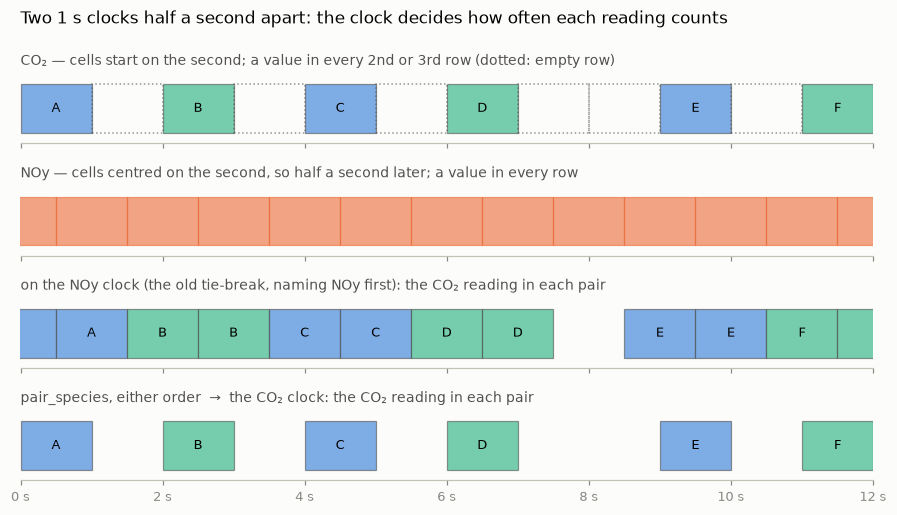

In [16]:
from tsara.core.support import overlap_pairs


def reading_in_each_pair(pairs_dataset):
    """Index of the CO₂ reading each pair's cell draws on (-1 for none)."""
    target = cells_of(pairs_dataset)
    link = overlap_pairs(CellBounds(start_ns=pic_start, stop_ns=pic_stop), target)
    real = np.isfinite(co2_obs[link.source_index]) & (link.overlap_ns > 0)
    reading = np.full(len(target), -1)
    reading[link.target_index[real]] = link.source_index[real]
    return reading


z0 = int(pic_start[40])
z1 = z0 + 12 * SECOND
letters = {}
for index in np.flatnonzero(has_value & (pic_start >= z0) & (pic_stop <= z1)):
    letters[int(index)] = "ABCDEFGHIJKLMNOP"[len(letters)]


def lane(ax, starts, stops, filled, label, tags=None, colours=None):
    """Draw one row of cells; label whole cells inside the window."""
    for i, (s, e) in enumerate(zip(starts, stops)):
        if e <= z0 or s >= z1:
            continue
        colour = colours[i] if colours is not None else C2
        ax.add_patch(
            plt.Rectangle(
                (s, 0.15),
                e - s,
                0.7,
                facecolor=colour if filled[i] else "none",
                edgecolor=colour if colours is None else INK2,
                alpha=0.6,
                lw=0.8 if filled[i] else 1.0,
                ls="-" if filled[i] else ":",
            )
        )
        if tags is not None and tags[i] and s >= z0 and e <= z1:
            ax.text(s + (e - s) / 2, 0.5, tags[i], ha="center", va="center", fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.text(0, 1.08, label, transform=ax.transAxes, fontsize=9, color=INK2, va="bottom")


def shade(tag):
    """Alternate two colours by reading, so neighbouring readings differ."""
    return C1 if "ABCDEFGHIJKLMNOP".index(tag) % 2 == 0 else C3


fig, axes = plt.subplots(4, 1, figsize=(10.0, 4.8), sharex=True, gridspec_kw={"hspace": 0.62})
pic_tags = [letters.get(i, "") for i in range(n_cells)]
lane(
    axes[0],
    pic_start,
    pic_stop,
    has_value,
    "CO₂ — cells start on the second; a value in every 2nd or 3rd row (dotted: empty row)",
    tags=pic_tags,
    colours=[shade(t) if t else C1 for t in pic_tags],
)
lane(
    axes[1],
    lif_start,
    lif_stop,
    np.ones(n_cells, dtype=bool),
    "NOy — cells centred on the second, so half a second later; a value in every row",
)
kept = on_noy.isel(time=np.flatnonzero(both))
rows9 = (
    (kept, "on the NOy clock (the old tie-break, naming NOy first): the CO₂ reading in each pair"),
    (
        pair_species(TIE_STREAMS, "noy", "co2").dataset,
        "pair_species, either order  →  the CO₂ clock: the CO₂ reading in each pair",
    ),
)
for ax, (pairs9, label) in zip(axes[2:], rows9):
    edges9 = pairs9["time_bnds"].values.astype("datetime64[ns]").astype("int64")
    tags = [letters.get(int(r), "") for r in reading_in_each_pair(pairs9)]
    lane(
        ax,
        edges9[:, 0],
        edges9[:, 1],
        np.ones(len(tags), dtype=bool),
        label,
        tags=tags,
        colours=[shade(t) if t else GRID for t in tags],
    )
axes[-1].set_xlim(z0, z1)
ticks = np.arange(z0, z1 + 1, 2 * SECOND)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{(tick - z0) / SECOND:.0f} s" for tick in ticks])
fig.suptitle(
    "Two 1 s clocks half a second apart: the clock decides how often each reading counts",
    x=0.125,
    ha="left",
    fontsize=11,
    y=1.0,
)
plt.show()

Read the bottom two rows against the top one. On the NOy clock, every CO₂
reading sits across the boundary between two NOy cells, so it half-covers each
and turns up in **both** pairs: A twice, B twice, C twice. On the CO₂ clock,
each reading is one pair, and the NOy value beside it is the average of the
two NOy cells it straddles.

Is that actually harmful? Two things suggest it might not be. The two
duplicate pairs carry *different* NOy values, so they are not pure copies. And
for an ordinary least-squares slope the two clocks are **algebraically
identical**: a reading that appears twice, once with each neighbour, pulls on
the line exactly as one appearance with the neighbours' mean does. The slope
cannot tell the two clocks apart.

The uncertainty can. What each copy duplicates is the CO₂ reading's *error*,
and a fit that counts the pairs as independent counts that error twice. Only
an experiment settles how much that costs, so: the same two clocks, a smooth
signal so the two instruments sample identical air to well within noise, and
the noise redrawn many times.

In [17]:
def one_realization(seed, sigma_co2, sigma_noy, sparse=True):
    """Smooth truth on the two clocks above, with fresh noise."""
    draw = np.random.default_rng(seed)
    mid_pic = (pic_start + pic_stop) / 2 / SECOND
    mid_lif = (lif_start + lif_stop) / 2 / SECOND

    def wave(t):
        return 10.0 * np.sin(2 * np.pi * (t - mid_pic[0]) / 600.0)

    co2 = 420.0 + wave(mid_pic) + draw.normal(0.0, sigma_co2, n_cells)
    if sparse:
        co2[~has_value] = np.nan
    noy = 2.0 + 8.0 * wave(mid_lif) + draw.normal(0.0, sigma_noy, n_cells)
    return {
        "picarro": stream_on(pic_start, pic_stop, co2=co2),
        "lif": stream_on(lif_start, lif_stop, noy=noy),
    }


def slope_and_naive_se(joined):
    """Least-squares NOy-on-CO₂ slope, and the standard error it reports."""
    keep = np.isfinite(joined["co2"].values) & np.isfinite(joined["noy"].values)
    x, y = joined["co2"].values[keep], joined["noy"].values[keep]
    design = np.vstack([x, np.ones_like(x)]).T
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    resid = y - design @ coef
    se = np.sqrt(resid @ resid / (x.size - 2) / ((x - x.mean()) ** 2).sum())
    return coef[0], se, x.size


CLOCKS = {"CO₂ cells": "picarro", "NOy cells": "lif"}
print(
    f"{'CO₂ record':>11} {'noise on CO₂':>13} {'clock':>10} {'pairs':>6} {'slope':>8} "
    f"{'real scatter':>13} {'naive SE':>9} {'naive/real':>11}"
)
for sparse in (True, False):
    for sigma_co2, sigma_noy in ((0.0, 1.0), (0.15, 1.0), (0.3, 0.5)):
        runs = {label: [] for label in CLOCKS}
        for seed in range(300):
            streams9 = one_realization(seed, sigma_co2, sigma_noy, sparse=sparse)
            for label, clock in CLOCKS.items():
                target = cells_of(streams9[clock])
                joined = bin_streams_onto_cells(streams9, target, ["co2", "noy"])
                runs[label].append(slope_and_naive_se(joined))
        for label, rows in runs.items():
            rows = np.array(rows)
            real = rows[:, 0].std(ddof=1)
            print(
                f"{'sparse' if sparse else 'dense':>11} {sigma_co2:>13.2f} {label:>10} "
                f"{rows[0, 2]:>6.0f} {rows[:, 0].mean():>8.4f} {real:>13.5f} "
                f"{rows[:, 1].mean():>9.5f} {rows[:, 1].mean() / real:>10.2f}x"
            )
    print()

 CO₂ record  noise on CO₂      clock  pairs    slope  real scatter  naive SE  naive/real


     sparse          0.00  CO₂ cells   1564   7.9998       0.00263   0.00253       0.96x
     sparse          0.00  NOy cells   3127   7.9998       0.00263   0.00263       1.00x


     sparse          0.15  CO₂ cells   1564   7.9961       0.00486   0.00497       1.02x
     sparse          0.15  NOy cells   3127   7.9961       0.00486   0.00401       0.82x


     sparse          0.30  CO₂ cells   1564   7.9853       0.00838   0.00863       1.03x
     sparse          0.30  NOy cells   3127   7.9853       0.00838   0.00621       0.74x



      dense          0.00  CO₂ cells   3599   7.9999       0.00237   0.00167       0.70x
      dense          0.00  NOy cells   3599   8.0002       0.00237   0.00236       0.99x


      dense          0.15  CO₂ cells   3599   7.9962       0.00383   0.00328       0.86x
      dense          0.15  NOy cells   3599   7.9982       0.00383   0.00309       0.81x


      dense          0.30  CO₂ cells   3599   7.9853       0.00578   0.00570       0.99x
      dense          0.30  NOy cells   3599   7.9927       0.00576   0.00416       0.72x



Start with the sparse rows, the case above. The slope is the same to every
printed digit on both clocks, as the algebra said. On the CO₂ cells — the
sparser member's, which `pair_species` now picks — the naive standard error
matches the slope's real scatter across draws, to within a few percent. On
the NOy cells it does too **until CO₂ has noise of its own**, and then it comes
out a fifth to a quarter too narrow. The bound is 1/√2, reached when all of
the error sits on the duplicated reading. So "no measurement is counted twice"
is not bookkeeping: it is what keeps a reported confidence interval honest.

**Now the dense rows, which the fix does not reach.** Fill every CO₂ row and
no reading is duplicated on either clock, yet whichever member gets averaged
lends each of its readings half to one pair and half to the next. Neighbouring
pairs then share an error, and the naive standard error is too narrow again on
*either* clock, by as much as 1/√2 when the averaged member's error dominates.
There is no good clock to pick here, and the reading count cannot flag it
either, because sharing a reading between two pairs is a correlation between
pairs rather than a shortfall of readings. Real drive data has this shape:
dense start-labelled species beside a dense mid-labelled one. It is recorded
in METHODS §11.4.1 as a question for the regression phase, which can see the
covariance that the shared overlap weights imply.

---
## 10. Angles: a direction is not a number

Everything so far averaged numbers. A wind direction is a point on a circle,
and the arithmetic mean of 359° and 1° is 180° — due south, from two readings
that were both essentially due north. So a variable declaring `circular: true`
takes a different path through the same join: every reading becomes a unit
vector, the vectors are averaged with **the same overlap weights** a scalar
would get, and the mean direction is the angle of the result.

Averaging vectors yields two numbers, not one. The second is the **mean
resultant length R**, the length of the average vector: 1 when every reading
agreed, 0 when they cancelled and there is no direction at all. TSARA stores
R, and next to it the exact circular standard deviation √(−2 ln R), in
degrees.

In [18]:
from tsara.core.circular import circular_mean

for label, readings in (
    ("359 and 1", [359.0, 1.0]),
    ("a steady wind", [40.0, 42.0, 38.0, 41.0]),
    ("a spread-out wind", [10.0, 70.0, 350.0, 300.0]),
    ("the four compass points", [0.0, 90.0, 180.0, 270.0]),
):
    result = circular_mean(readings)
    print(
        f"{label:24} arithmetic {np.mean(readings):6.1f}   vector {result.mean_deg:6.1f}   "
        f"R {result.resultant_length:.3f}   dispersion {result.dispersion_deg:6.1f}"
    )

359 and 1                arithmetic  180.0   vector    0.0   R 1.000   dispersion    1.0
a steady wind            arithmetic   40.2   vector   40.3   R 1.000   dispersion    1.5
a spread-out wind        arithmetic  182.5   vector    1.5   R 0.703   dispersion   48.1
the four compass points  arithmetic  135.0   vector    nan   R 0.000   dispersion    inf


The last row is worth a second look. Mathematically the four compass points
cancel exactly; in floating point `sin(180°)` is 1.2e-16 rather than zero, so
a residual vector survives and points somewhere confidently, and somewhere
*different* when the same four readings are added in a different order. TSARA
treats a resultant at or below the rounding floor of its own sum as
cancellation: no direction (`nan`), R = 0, infinite dispersion — three numbers
saying the same thing. That threshold is a fact about float64, not a judgement
about wind; no *scientific* cut-off on R is applied anywhere.

Here is the difference on a record that behaves like a vane: a wind veering
from 320° through north to 40° over an hour, steady for forty minutes and then
starting to tumble.

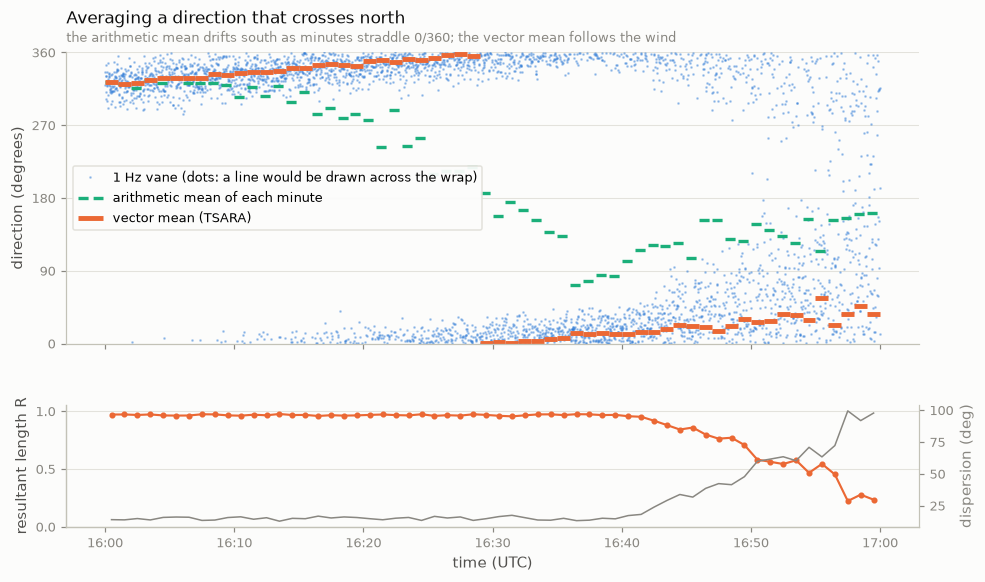

minutes where the arithmetic mean is more than 45° wrong: 44 of 60


In [19]:
from tsara.core.support import CellBounds

rng10 = np.random.default_rng(12)
N10 = 3600
t10 = pd.Timestamp("2026-06-18T16:00:00")
vane_start = t10.value + np.arange(N10, dtype=np.int64) * SECOND
heading = 320.0 + 80.0 * np.arange(N10) / N10  # veers through north
spread = np.where(np.arange(N10) < 2400, 15.0, 15.0 + 75.0 * (np.arange(N10) - 2400) / 1200)
vane_values = (heading + rng10.normal(0.0, 1.0, N10) * spread) % 360.0

vane = xr.Dataset(
    {"wind_dir": ("time", vane_values, {"units": "degrees", "circular": 1, "role": "met"})},
    coords={
        "time": (vane_start + SECOND // 2).astype("datetime64[ns]"),
        "time_bnds": (
            ("time", "nv"),
            np.stack([vane_start, vane_start + SECOND], axis=1).astype("datetime64[ns]"),
        ),
    },
)
vane["time"].attrs["bounds"] = "time_bnds"

minute_start = t10.value + np.arange(60, dtype=np.int64) * 60 * SECOND
minutes = CellBounds(start_ns=minute_start, stop_ns=minute_start + 60 * SECOND)
on_minutes = bin_streams_onto_cells({"vane": vane}, minutes, ["wind_dir"])
# Built by hand, NOT by TSARA: what an ordinary resample-mean would report.
arithmetic = vane_values.reshape(60, 60).mean(axis=1)
m_start = minute_start.astype("datetime64[ns]")
m_stop = (minute_start + 60 * SECOND).astype("datetime64[ns]")

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(10.0, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.3}
)
ax.plot(
    vane["time"].values,
    vane_values,
    ".",
    color=C1,
    ms=1.6,
    alpha=0.35,
    label="1 Hz vane (dots: a line would be drawn across the wrap)",
)
ax.hlines(
    arithmetic,
    m_start,
    m_stop,
    color=C3,
    lw=2.2,
    ls=(0, (3, 1.5)),
    label="arithmetic mean of each minute",
)
ax.hlines(
    on_minutes["wind_dir"].values, m_start, m_stop, color=C2, lw=3.2, label="vector mean (TSARA)"
)
ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360])
finish(
    ax,
    "Averaging a direction that crosses north",
    "the arithmetic mean drifts south as minutes straddle 0/360; the vector mean follows the wind",
    "direction (degrees)",
)
ax.legend(
    loc="center left",
    fontsize=8.2,
    frameon=True,
    facecolor=SURFACE,
    edgecolor=GRID,
    framealpha=0.95,
)
axr.plot(
    on_minutes["time"].values, on_minutes["wind_dir_resultant_length"].values, "o-", color=C2, ms=3
)
axr.set_ylim(0, 1.05)
axd = axr.twinx()
axd.plot(
    on_minutes["time"].values, on_minutes["wind_dir_dispersion"].values, "-", color=MUTED, lw=1.0
)
axd.set_ylabel("dispersion (deg)", color=MUTED)
axd.tick_params(axis="y", colors=MUTED)
axd.spines["right"].set_visible(True)
finish(axr, None, None, "resultant length R", "time (UTC)")
hhmm(axr)
plt.show()

gap = np.abs((arithmetic - on_minutes["wind_dir"].values + 180.0) % 360.0 - 180.0)
print(f"minutes where the arithmetic mean is more than 45° wrong: {int((gap > 45).sum())} of 60")

The green dashes are what a plain resample would have stored, and they are
not a little wrong: once a minute holds readings on both sides of north, the
average of 350s and 10s lands in the 180s. The orange bars follow the wind
through north without noticing it.

The lower panel is the part a direction alone cannot tell you. For forty
minutes R sits near 0.97 and the dispersion near 15°: the direction means
something. As the wind starts to tumble R falls and the dispersion climbs past
90°, and by the end the "mean direction" of a minute is a number that exists
but describes very little. TSARA reports it anyway, beside the R that says so.

One choice is worth naming. These are **unit-vector** means: every reading
counts equally whatever the wind speed. The other convention weights each
reading by its speed, which gives the direction the air actually moved in on
average rather than the direction the vane usually pointed. On a real drive the
two differ by a few degrees in a typical minute and by more when the wind is
light and variable (METHODS §11.5). TSARA uses unit vectors because the join
does not know which speed goes with which direction, and should not have to.

---
### How much R can say depends on how many readings made it

R is a statistic of a sample, and with only a few readings it cannot get near
zero even when the directions carry no information at all: two random readings
have an average R of about 0.64. The dispersion is understated for the same
reason. That matters in exactly the places this phase creates: a 1 Hz wind
averaged over a 15 s canister fill contributes about fifteen readings, over a
10 s analyzer cell about ten.

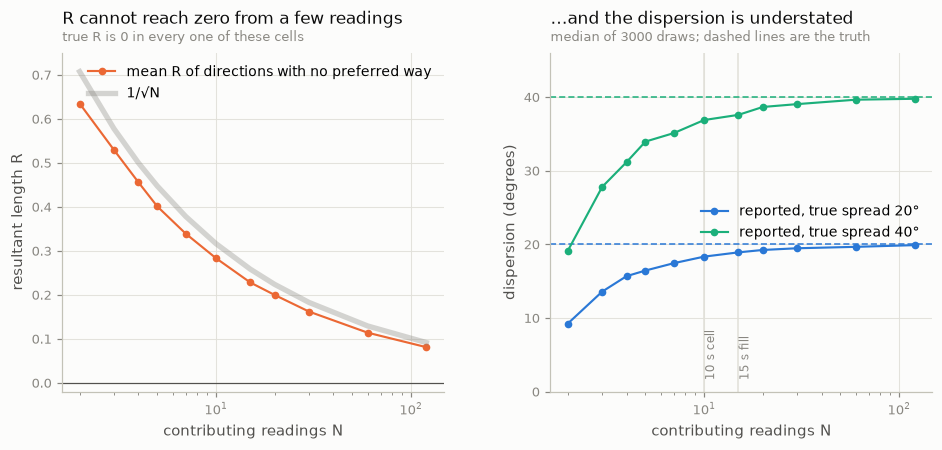

In [20]:
rng_n = np.random.default_rng(2)
readings_per_cell = np.array([2, 3, 4, 5, 7, 10, 15, 20, 30, 60, 120])
DRAWS = 3000
r_random = [
    np.mean([circular_mean(rng_n.uniform(0, 360, n)).resultant_length for _ in range(DRAWS)])
    for n in readings_per_cell
]
reported = {
    spread_deg: [
        np.median(
            [circular_mean(rng_n.normal(0, spread_deg, n)).dispersion_deg for _ in range(DRAWS)]
        )
        for n in readings_per_cell
    ]
    for spread_deg in (20.0, 40.0)
}

fig, (axl, axq) = plt.subplots(1, 2, figsize=(10.2, 4.0), gridspec_kw={"wspace": 0.28})
axl.semilogx(
    readings_per_cell,
    r_random,
    "o-",
    color=C2,
    ms=4,
    label="mean R of directions with no preferred way",
)
axl.semilogx(
    readings_per_cell,
    1 / np.sqrt(readings_per_cell),
    "-",
    color=MUTED,
    lw=3.5,
    alpha=0.35,
    label="1/√N",
)
axl.axhline(0, color=INK2, lw=0.8)
axl.set_ylim(-0.02, 0.75)
finish(
    axl,
    "R cannot reach zero from a few readings",
    "true R is 0 in every one of these cells",
    "resultant length R",
    "contributing readings N",
    legend=True,
    loc="upper right",
    grid_axis="both",
)
for spread_deg, colour in zip(reported, (C1, C3)):
    axq.semilogx(
        readings_per_cell,
        reported[spread_deg],
        "o-",
        color=colour,
        ms=4,
        label=f"reported, true spread {spread_deg:.0f}°",
    )
    axq.axhline(spread_deg, color=colour, lw=1.0, ls=(0, (4, 2)))
for n_mark, name in ((10, "10 s cell"), (15, "15 s fill")):
    axq.axvline(n_mark, color=GRID, lw=1.0, zorder=0)
    axq.text(n_mark, 1, f" {name}", fontsize=8, color=MUTED, rotation=90, va="bottom")
axq.set_ylim(0, 46)
finish(
    axq,
    "…and the dispersion is understated",
    "median of 3000 draws; dashed lines are the truth",
    "dispersion (degrees)",
    "contributing readings N",
    legend=True,
    loc="center right",
    grid_axis="both",
)
plt.show()

Both panels converge on the truth, and by sixty readings the difference is a
degree or two. Below ten it is not small: five readings of a wind whose true
spread is 40° report about 34°, and five random readings report an R near 0.4,
which on its own would read as "moderately steady".

TSARA does not correct for this, and the reason is the one it gives for every
other quality number: the correction needs an assumption about the underlying
distribution, and `n_source` travels with every binned direction, so the
reader can see when R rests on a handful of readings. It is a caveat worth
knowing rather than a defect.

---
### A declared conversion can carry a direction across north

Unit conversion comes before QA/QC at ingestion, deliberately: a range bound is
a physical statement in canonical units. For a direction the most common
conversion is an offset, turning a magnetic bearing into a true one, and the
most natural QA/QC rule is a range of 0 to 360. Here is a vane whose readings
straddle magnetic north, corrected by a declination of +10.3°.

In [21]:
vane_dir = WORK / "vane"
vane_dir.mkdir(exist_ok=True)
stamps = pd.date_range("2026-01-19 20:00:00", periods=8, freq="1s")
magnetic = [352.0, 355.0, 358.0, 1.0, 3.0, 350.0, 357.0, 359.0]
pd.DataFrame({"time": stamps.strftime("%Y-%m-%d %H:%M:%S"), "wdir_mag": magnetic}).to_csv(
    vane_dir / "met.csv", index=False
)
(vane_dir / "manifest.yaml").write_text(
    f"""
name: declination_demo
base_path: {vane_dir}
platform: {{kind: stationary, latitude: 40.76, longitude: -111.89}}
instruments:
  vane:
    loader:
      format: csv
      path_template: "met.csv"
      time: {{column: time, format: "%Y-%m-%d %H:%M:%S", timezone: UTC}}
    variables:
      wind_dir:
        column: wdir_mag
        role: met
        units: degrees
        circular: true
        convert: {{from_unit: degrees_magnetic, to_unit: degrees, scale: 1.0, offset: 10.3}}
        qaqc:
          - {{kind: range, min: 0, max: 360}}
"""
)
corrected = ingest_campaign(load_manifest(vane_dir / "manifest.yaml"))["vane"]
print("magnetic, as written :", magnetic)
print("true, as ingested    :", corrected["wind_dir"].values.round(1).tolist())
print("masked by the range rule:", corrected["wind_dir"].attrs["masked_fraction"])

magnetic, as written : [352.0, 355.0, 358.0, 1.0, 3.0, 350.0, 357.0, 359.0]
true, as ingested    : [2.3, 5.3, 8.3, 11.3, 13.3, 0.3, 7.3, 9.3]
masked by the range rule: 0.0


Every reading arrives, on one turn. 352° magnetic is 2.3° true, not 362.3°.

Until walkthrough stage 4 of this phase, ingestion converted and then applied
QA/QC without wrapping in between, and this same manifest came back as
`[nan, nan, nan, 11.3, 13.3, nan, nan, nan]`: every reading within 10.3° west
of north exceeded 360 after the offset and the range rule masked it. That is
not a random fraction of a record but a whole sector of the wind rose, and
nothing about the stream said so. A direction declaring `circular: true` is
now wrapped between conversion and QA/QC, which is exact and changes no
direction.

---
### A direction keeps its columns whichever path it takes

One last property, and it is about the join rather than the angles. A stream
already on the target cells skips the averaging, because averaging a cell onto
itself is the identity only mathematically. The columns that come *with* the
value must not skip anything, or a product's columns would depend on whether a
stream happened to share the target's cells — which is exactly what a sweep
over grid period changes.

In [22]:
seconds = cells_of(vane)
for label, target in (("its own 1 s cells", seconds), ("60 s cells", minutes)):
    out = bin_streams_onto_cells({"vane": vane}, target, ["wind_dir"])
    columns = sorted(map(str, out.data_vars))
    print(f"{label:18} binned={out['wind_dir'].attrs['tsara_binned']}  {columns}")

its own 1 s cells  binned=0  ['coverage_wind_dir', 'n_source_wind_dir', 'wind_dir', 'wind_dir_dispersion', 'wind_dir_resultant_length']
60 s cells         binned=1  ['coverage_wind_dir', 'n_source_wind_dir', 'wind_dir', 'wind_dir_dispersion', 'wind_dir_resultant_length']


The same five columns either way. On its own cells each reading is one
contributing reading, so its resultant length is 1 and its dispersion 0 — what
vector-averaging a single reading returns — and a masked reading contributes no
count and no coverage, on either path. Before this stage the pass-through gave
a direction neither quality column, and stamped a count and coverage of 1 on
masked rows of every variable.

---
## 11. The one interpolation, and what it costs

Everything so far has been averaging. This section is the single place TSARA
*interpolates*: it evaluates a field between two samples, at an instant nobody
measured. The prohibition from earlier still stands — a concentration inside a
plume is not a smooth field, so a gas is never interpolated — and the exception
is narrow. Position and ambient meteorology change smoothly on sampling
timescales, so a value between two fixes is a physically reasonable estimate
**if the fixes are close enough together**.

Two guards, both refusals. A variable declaring `role: gas` is refused, and so
is one declaring no role at all, since its smoothness is unknown. And a target
whose two bracketing samples are further apart than `max_interp_gap` gets
`nan` rather than a straight line across the gap.

In [23]:
from tsara.align import attach_positions, interpolate_onto_cells

for label, streams11, name in (
    ("a gas (canister benzene, role: gas)", canister.streams, "benzene"),
    ("a variable with no role (section 9's NOy)", TIE_STREAMS, "noy"),
):
    try:
        interpolate_onto_cells(streams11, name, minutes)
    except TsaraAlignError as refused:
        print(f"{label}:\n    {str(refused).split('. ')[0]}.\n")

a gas (canister benzene, role: gas):
    'benzene' on 'iwas' has role 'gas' and will not be interpolated.

a variable with no role (section 9's NOy):
    'noy' on 'lif' declares no role, so TSARA cannot tell whether interpolating it is physically justified.



The realistic use is a moving platform. Ingestion attaches a stationary site's
single position, which is exact, but deliberately leaves a moving platform's
track alone: putting GPS onto a gas instrument's clock is interpolation, and
its guard belongs here. Below, a van drives a wandering route for thirty
minutes. The generator records its position every second, which serves as the
true track. The raw files are written and ingested exactly as a real archive
would be, and then the GPS record is **thinned to one fix every 10 s with a
40 s outage**, the shape a real low-rate GPS log has.

In [24]:
DRIVE = {
    "name": "drive_demo",
    "seed": 3,
    "start": "2026-06-19T15:00:00Z",
    "duration": "30min",
    "platform": {
        "kind": "mobile",
        "gps_instrument": "gps",
        "gps_rate": "1s",
        "start_latitude": 40.76,
        "start_longitude": -111.89,
        "speed_m_s": 13.0,
        "pattern": "random_walk",
        "heading_volatility": 0.1,
    },
    "instruments": {
        "analyzer": {
            "native_rate": "1s",
            "species": {
                "ch4": {
                    "background": {"kind": "parametric", "offset": 1950.0},
                    "role": "gas",
                    "units": "ppb",
                }
            },
        }
    },
    "sources": {},
}
drive = generate(SyntheticConfig.model_validate(DRIVE))
drive_streams = ingest_campaign(load_manifest(export_raw(drive, WORK / "drive")))
analyzer = drive_streams["analyzer"]
print("ingested analyzer coordinates:", sorted(map(str, analyzer.coords)))
print("its GPS binding              :", analyzer.attrs["platform_gps_instrument"])

gps_full = drive_streams["gps"]
fix_time = gps_full["time"].values
every_tenth = np.zeros(fix_time.size, dtype=bool)
every_tenth[::10] = True
outage = (fix_time >= fix_time[0] + np.timedelta64(700, "s")) & (
    fix_time < fix_time[0] + np.timedelta64(740, "s")
)
thinned = gps_full.isel(time=np.flatnonzero(every_tenth & ~outage))
placed = attach_positions(analyzer, {**drive_streams, "gps": thinned}, max_interp_gap="10s")

METRES = 111_320.0
cos_lat = np.cos(np.radians(40.76))
true_lat = drive.streams["analyzer"]["latitude"].sel(time=placed["time"]).values
true_lon = drive.streams["analyzer"]["longitude"].sel(time=placed["time"]).values
error_m = np.hypot(
    (placed["latitude"].values - true_lat) * METRES,
    (placed["longitude"].values - true_lon) * METRES * cos_lat,
)
positioned = np.isfinite(error_m)
print(
    f"\ncells positioned: {positioned.sum()} of {positioned.size}; "
    f"refused across the outage: {placed['latitude'].attrs['tsara_interp_gap_masked']}"
)
print(
    f"error against the 1 s track: median {np.median(error_m[positioned]):.1f} m, "
    f"p90 {np.percentile(error_m[positioned], 90):.1f} m, max {error_m[positioned].max():.1f} m"
)

ingested analyzer coordinates: ['time', 'time_bnds']
its GPS binding              : gps

cells positioned: 1742 of 1800; refused across the outage: 49
error against the 1 s track: median 2.5 m, p90 7.2 m, max 18.3 m


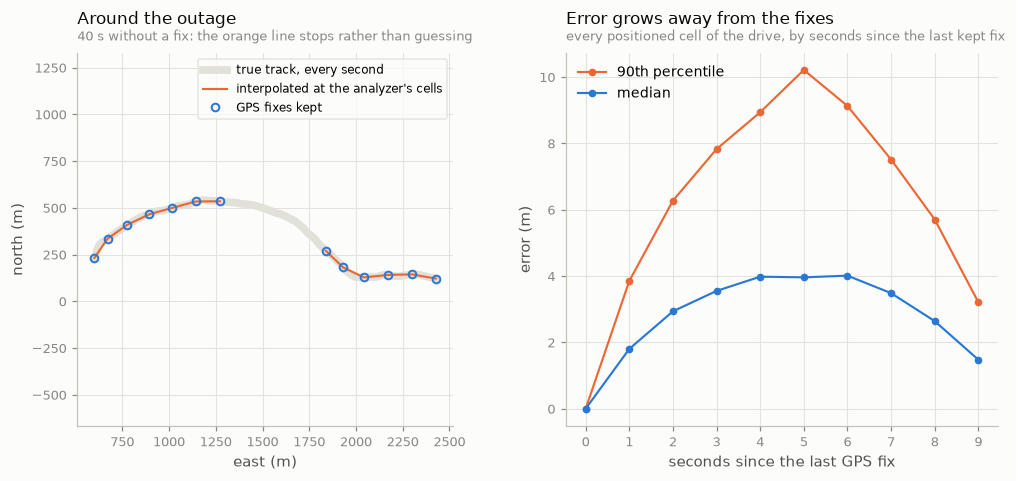

In [25]:
def east(lon):
    """Metres east of the drive's start longitude."""
    return (np.asarray(lon) + 111.89) * METRES * cos_lat


def north(lat):
    """Metres north of the drive's start latitude."""
    return (np.asarray(lat) - 40.76) * METRES


gap_start = fix_time[0] + np.timedelta64(700, "s")
around = (gap_start - np.timedelta64(60, "s"), gap_start + np.timedelta64(100, "s"))
truth_near = drive.streams["gps"].sel(time=slice(*around))
placed_near = placed.sel(time=slice(*around))
fixes_near = thinned.sel(time=slice(*around))

# Error against how long since the last kept fix: the shape interpolation error
# has, rather than a thirty-minute sawtooth of it.
fix_ns = thinned["time"].values.astype("datetime64[ns]").astype("int64")
cell_ns = placed["time"].values.astype("datetime64[ns]").astype("int64")
since = cell_ns - fix_ns[np.clip(np.searchsorted(fix_ns, cell_ns, side="right") - 1, 0, None)]
since_s = np.round(since / SECOND).astype(int)
offsets = np.arange(10)
median_by = [np.median(error_m[positioned & (since_s == k)]) for k in offsets]
p90_by = [np.percentile(error_m[positioned & (since_s == k)], 90) for k in offsets]

fig = plt.figure(figsize=(10.8, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.15], wspace=0.28)
axm = fig.add_subplot(gs[0, 0])
axe = fig.add_subplot(gs[0, 1])
axm.plot(
    east(truth_near["longitude"]),
    north(truth_near["latitude"]),
    color=GRID,
    lw=5.0,
    label="true track, every second",
)
axm.plot(
    east(placed_near["longitude"]),
    north(placed_near["latitude"]),
    color=C2,
    lw=1.4,
    label="interpolated at the analyzer's cells",
)
axm.plot(
    east(fixes_near["longitude"]),
    north(fixes_near["latitude"]),
    "o",
    color=C1,
    ms=5,
    mfc="none",
    mew=1.3,
    label="GPS fixes kept",
)
axm.set_aspect("equal", adjustable="datalim")
finish(
    axm,
    "Around the outage",
    "40 s without a fix: the orange line stops rather than guessing",
    "north (m)",
    "east (m)",
    grid_axis="both",
)
axm.legend(fontsize=7.8, loc="best", frameon=True, facecolor=SURFACE, edgecolor=GRID)

axe.plot(offsets, p90_by, "o-", color=C2, ms=4, label="90th percentile")
axe.plot(offsets, median_by, "o-", color=C1, ms=4, label="median")
axe.set_xticks(offsets)
finish(
    axe,
    "Error grows away from the fixes",
    "every positioned cell of the drive, by seconds since the last kept fix",
    "error (m)",
    "seconds since the last GPS fix",
    legend=True,
    loc="upper left",
    grid_axis="both",
)
plt.show()

On the left, the orange line follows the grey one and then stops: forty
seconds of track is simply not drawn, because a straight line across it would
be a guess, and the analyzer cells inside the outage carry no position. On the
right is the shape of the error everywhere else. A cell that falls on a kept
fix is exact; the further it sits from one, the more the van has had time to
turn away from the straight chord between two fixes, and the error peaks
mid-way between them.

That error is the whole content of `max_interp_gap`. The guard is not a
technicality: it is a statement about how far a platform may be allowed to
stray from a straight line between fixes. Measured on real city driving, at a
median speed of 13 m/s, bridging 10 s gaps costs about 10 m at the 90th
percentile, 50 s gaps about 110 m, and 60 s gaps about 140 m (METHODS §11.6).
Whether 100 m is acceptable depends on what the position is for, which is why
it is a configuration value rather than a constant.

---
### When a record's own spacing is wider than the guard

In [26]:
import logging

from tsara import setup_logging

# TSARA's warnings are silent in a notebook until logging is set up; the whole
# point of this cell is what it reports.
setup_logging(logging.WARNING)

sparse_gps = gps_full.isel(time=slice(None, None, 50))  # one fix every 50 s
sparse = interpolate_onto_cells(
    {**drive_streams, "gps": sparse_gps},
    ("gps", "latitude"),
    cells_of(analyzer),
    max_interp_gap="10s",
)
print(
    f"fix every 50 s, guard 10 s: {sparse.n_exact} exact, {sparse.n_interpolated} "
    f"interpolated, {sparse.n_gap_masked} refused, {sparse.n_outside} outside"
)

2026-09-14 14:12:08 | WARNING  | tsara.align.auxiliary | 'latitude' on 'gps' is sampled every 50 s (median), longer than max_interp_gap=10s, so the guard refused 1715 of 1800 cells and only the 36 landing exactly on a sample kept a value. That is the guard working as configured. If bridging 50 s is acceptable for this field, raise max_interp_gap; METHODS §11.6 tabulates what that costs for a moving platform's position.


fix every 50 s, guard 10 s: 36 exact, 0 interpolated, 1715 refused, 49 outside


Almost every cell is refused, which is correct: a 10 s guard says no gap wider
than 10 s may be bridged, and every gap in this record is 50 s. What is left is
worth a second look — a handful of cells whose midpoints land *exactly* on a
fix keep a position, because those values were measured rather than
interpolated. The result is a record positioned at one cell in fifty, which
at a glance looks like a join that worked.

Nothing about that is wrong, but until walkthrough stage 5 of this phase
nothing about it announced itself either: the only record was an informational
log line. Real archives have exactly this shape — a mobile-lab GPS logging
every 50 s is in the 2024 data — so the warning above now fires whenever the
record's own median spacing is longer than the guard. The fix it suggests is
deliberately not automatic, because widening the guard is a decision about how
wrong a position may be, which the table in METHODS §11.6 quantifies.

---
### An instant is not an interval

Interpolation evaluates a field at the **midpoint** of each target cell. For a
sparse record that is the only option: a fix every 10 s cannot fill 1 s cells
by averaging. For a *dense* record placed on *wider* cells it throws most of
the record away and reports one instant for a value that describes an
interval. The vane from section 10 shows the difference, on 15 s cells the
width of a canister fill:

In [27]:
fill_start = t10.value + np.arange(240, dtype=np.int64) * 15 * SECOND
fills15 = CellBounds(start_ns=fill_start, stop_ns=fill_start + 15 * SECOND)
at_midpoint = interpolate_onto_cells({"vane": vane}, "wind_dir", fills15, max_interp_gap="10s")
averaged = bin_streams_onto_cells({"vane": vane}, fills15, ["wind_dir"])
apart = np.abs((at_midpoint.values - averaged["wind_dir"].values + 180.0) % 360.0 - 180.0)
steady = averaged["wind_dir_resultant_length"].values > 0.9
print(
    f"15 s cells, midpoint instant vs cell vector mean: median {np.median(apart):.1f}°, "
    f"p90 {np.percentile(apart, 90):.1f}°, max {apart.max():.1f}°"
)
print(
    f"  where the wind was steady (R > 0.9): median {np.median(apart[steady]):.1f}°; "
    f"where it was not: median {np.median(apart[~steady]):.1f}°"
)

15 s cells, midpoint instant vs cell vector mean: median 12.3°, p90 53.3°, max 161.1°
  where the wind was steady (R > 0.9): median 9.2°; where it was not: median 36.6°


Even in the steady forty minutes the instant is about 9° from the average,
which is simply the noise of the one or two readings an instant is built from;
once the wind tumbles the median is several times that, and the worst cell is
off by more than 160°. Only the average comes with an R saying how much the
direction means.

So the rule of thumb is: **bin a field that is denser than the cells,
interpolate one that is sparser.** The output grid follows it — met is binned
onto the grid, never interpolated. `attach_positions` interpolates because a
GPS record is often the sparser one, and because for a *position* the instant
costs little: on a real drive a canister fill's midpoint position sits within
a few metres of its mean position, against more than a hundred metres of road
covered during the fill (METHODS §11.6).